# Time-Varying Barrier Certificate Data Analysis

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

## Circle Swap with Obstacles

### Description

Robots start equally spaced around a 0.9m radius circle and are told to travel in a straight line through the circle to the other side.  While attempting to traverse to the other side the robots must avoid each other as well as two obstacles at (0.3, 0.2) and (-0.3, -0.2) at a minimum safe radius of 0.2 meters.

In [2]:
circle_swap_data = pl.read_csv("./data/sim/circle_swap_with_obstacles.csv")
circle_swap_data

Barrier Name,N,Completion Time (s),Negative Iterations
str,i64,f64,i64
"""circular""",4,20.394,0
"""circular""",8,-1.0,0
"""circular""",11,40.227,0
"""circular""",16,-1.0,0
"""circular""",20,-1.0,3383
…,…,…,…
"""delta(circular-elliptical-squa…",4,71.874,0
"""delta(circular-elliptical-squa…",8,97.482,0
"""delta(circular-elliptical-squa…",11,64.086,0


#### Completion Times

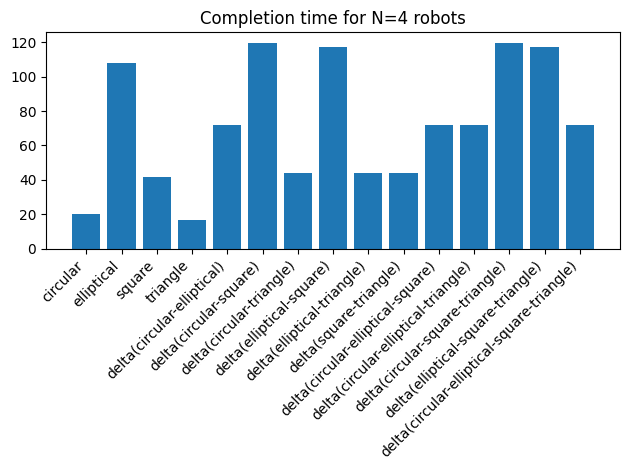

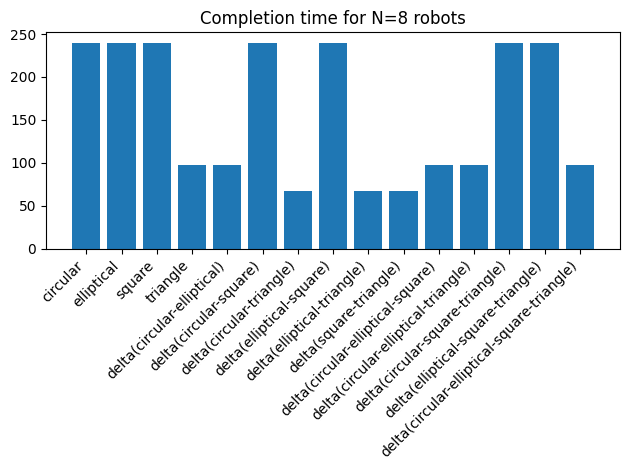

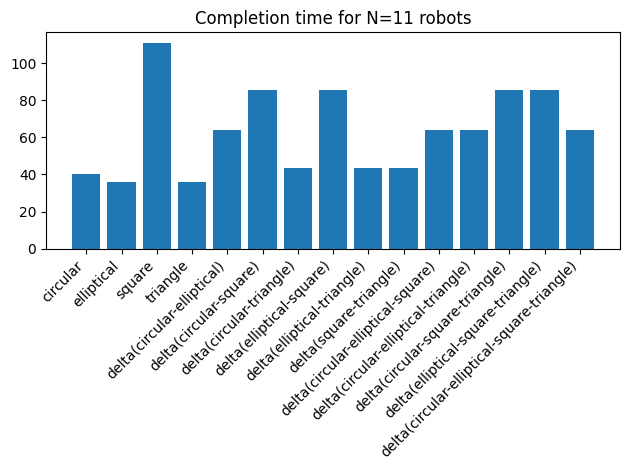

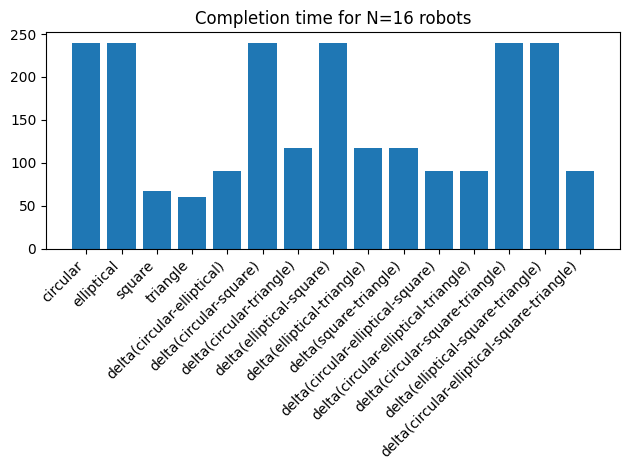

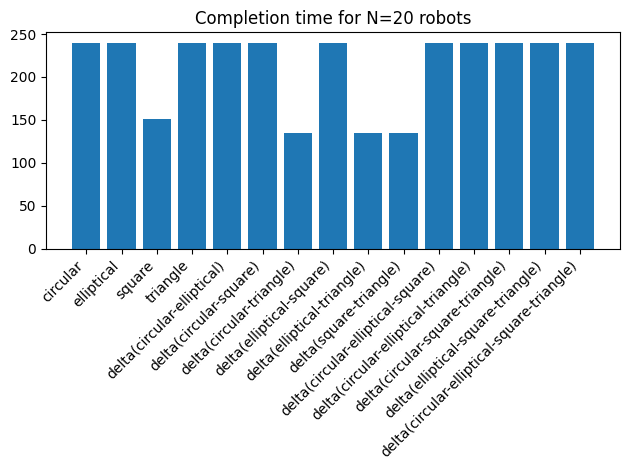

In [11]:
for N in [4, 8, 11, 16, 20]:
    subset = circle_swap_data.filter(pl.col("N") == N)
    fig, ax = plt.subplots()
    ax.bar(range(len(subset["Barrier Name"])), subset["Completion Time (s)"].replace(-1, 240))
    ax.set_xticks(range(len(subset["Barrier Name"])))
    ax.set_xticklabels(subset["Barrier Name"], rotation=45, ha="right")
    ax.set_title(f"Completion time for N={N} robots")
    fig.tight_layout()
    plt.show()


#### Negative Iterations

In [ ]:
for N in [4, 8, 11, 16, 20]:
    subset = circle_swap_data.filter(pl.col("N") == N)
    fig, ax = plt.subplots()
    ax.bar(range(len(subset["Barrier Name"])), subset["nh"])
    ax.set_xticks(range(len(subset["Barrier Name"])))
    ax.set_xticklabels(subset["Barrier Name"], rotation=45, ha="right")
    ax.set_title(f"Completion time for N={N} robots")
    fig.tight_layout()
    plt.show()


## Random Goals with Obstacles

### Description

Robots start equally spaced in 1-2 lines within a rectangle of size 2.5 x 1.6 meters.  A set of goals are randomly generated in another rectangle on the opposite side of the robotarium that the robots must go to.  While attempting to reach the goal the robots must avoid each other and two obstacles placed at (-0.6, 0) and (0.6, 0) at a safe radius of 0.16 meters